Pipline()

Data Manager (Download, organize with_mask/without_mask folders, verify quality)

In [ ]:
!pip install torch torchvision fastapi uvicorn python-multipart Pillow scikit-learn

In [ ]:
import kagglehub
import os
import pandas as pd
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter
import matplotlib.pyplot as plt
import random
import torch
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("ashishjangra27/face-mask-12k-images-dataset")

print("Dataset path:", path)
print("Files:", os.listdir(path))

100%|██████████| 330M/330M [00:22<00:00, 15.1MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/ashishjangra27/face-mask-12k-images-dataset/versions/1
Files: ['Face Mask Dataset']


In [ ]:
train_data = datasets.ImageFolder(root=os.path.join(path, "Face Mask Dataset/Train"))
val_data   = datasets.ImageFolder(root=os.path.join(path, "Face Mask Dataset/Validation"))
test_data  = datasets.ImageFolder(root=os.path.join(path, "Face Mask Dataset/Test"))

In [ ]:
print(len(train_data))
print(train_data.classes)

10000
['WithMask', 'WithoutMask']


In [ ]:
class_counts = Counter(train_data.targets)
classes = train_data.classes

for cls, count in zip(classes, [class_counts[i] for i in range(len(classes))]):
    print(f"{cls}: {count} images")

WithMask: 5000 images
WithoutMask: 5000 images


In [ ]:
print(len(val_data))
print(val_data.classes)

800
['WithMask', 'WithoutMask']


In [ ]:
class_counts = Counter(val_data.targets)
classes = val_data.classes

for cls, count in zip(classes, [class_counts[i] for i in range(len(classes))]):
    print(f"{cls}: {count} images")

WithMask: 400 images
WithoutMask: 400 images


In [ ]:
print(len(test_data))
print(test_data.classes)

992
['WithMask', 'WithoutMask']


In [ ]:
class_counts = Counter(test_data.targets)
classes = test_data.classes

for cls, count in zip(classes, [class_counts[i] for i in range(len(classes))]):
    print(f"{cls}: {count} images")

WithMask: 483 images
WithoutMask: 509 images


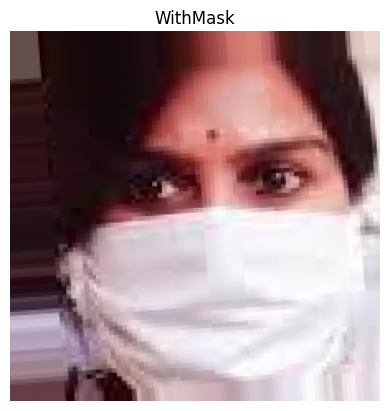

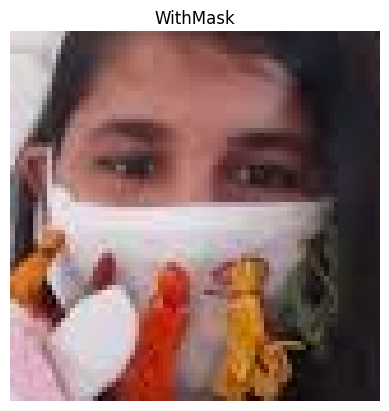

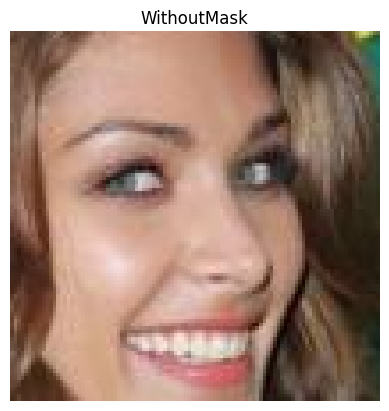

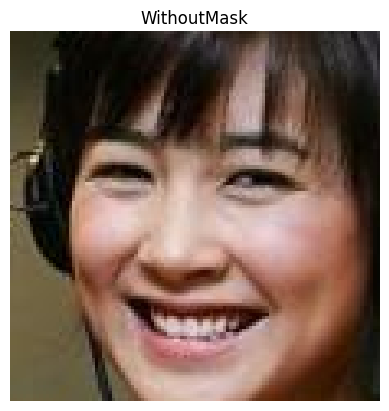

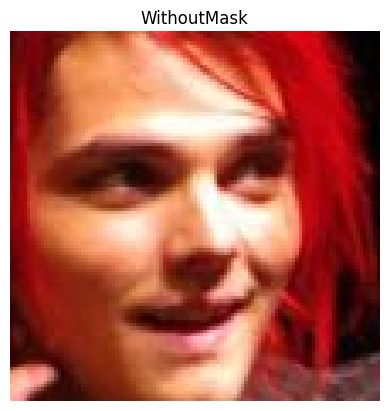

In [ ]:
for i in range(5):
    img, label = train_data[random.randint(0, len(train_data)-1)]
    plt.imshow(img)
    plt.title(train_data.classes[label])
    plt.axis("off")
    plt.show()

EDA & Visualizer (Sample images per class, face diversity analysis, statistics)

In [ ]:
def sampleImagesPerClass(dataset, class_name, n=2):
    class_idx = dataset.class_to_idx[class_name]
    samples = [s for s in dataset.samples if s[1] == class_idx]

    for i in range(n):
        img_path, _ = random.choice(samples)
        img = plt.imread(img_path)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
        plt.show()

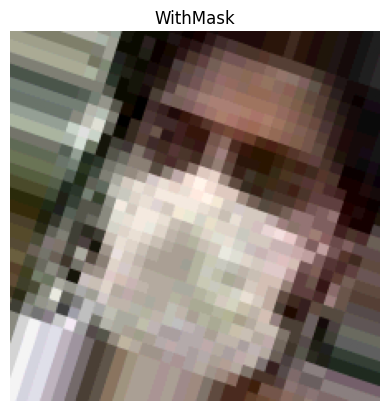

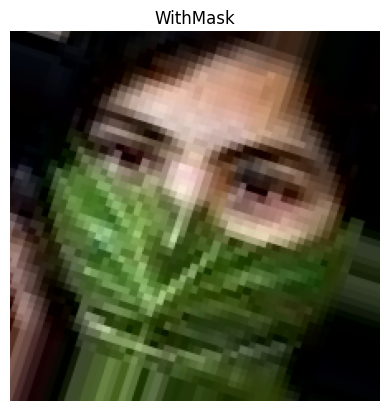

In [ ]:
sampleImagesPerClass(train_data, "WithMask")

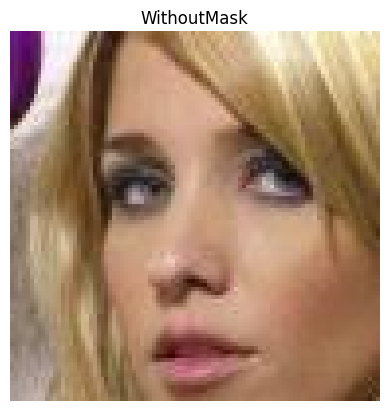

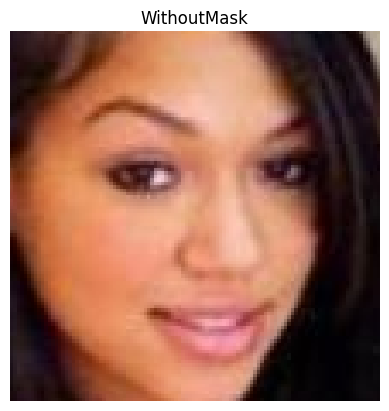

In [ ]:
sampleImagesPerClass(train_data, "WithoutMask")

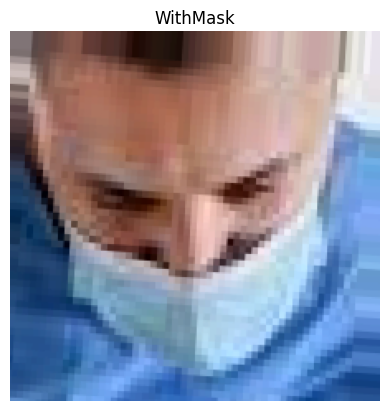

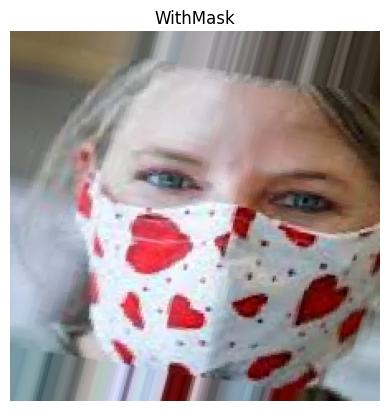

In [ ]:
sampleImagesPerClass(val_data, "WithMask")

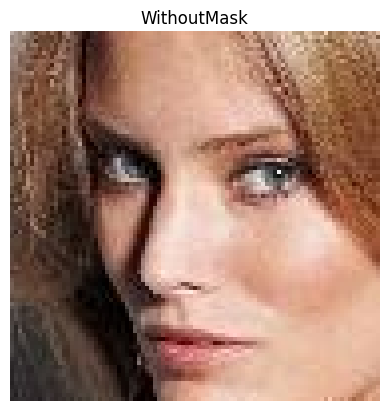

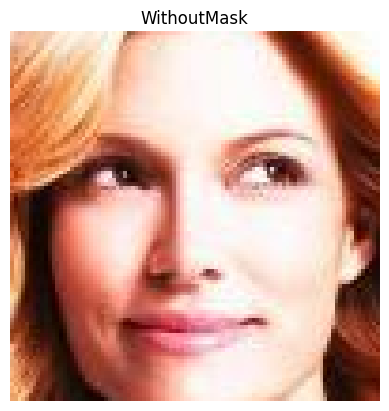

In [ ]:
sampleImagesPerClass(val_data, "WithoutMask")

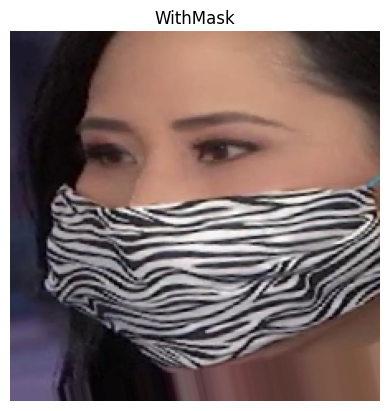

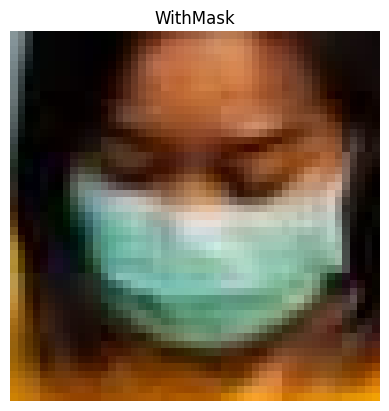

In [ ]:
sampleImagesPerClass(test_data, "WithMask")

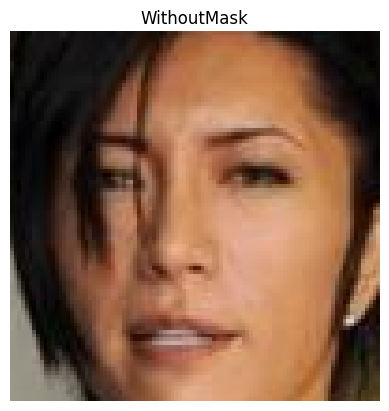

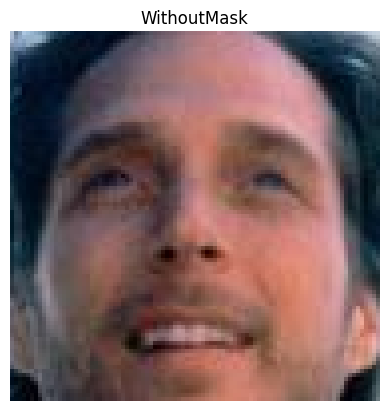

In [ ]:
sampleImagesPerClass(test_data, "WithoutMask")

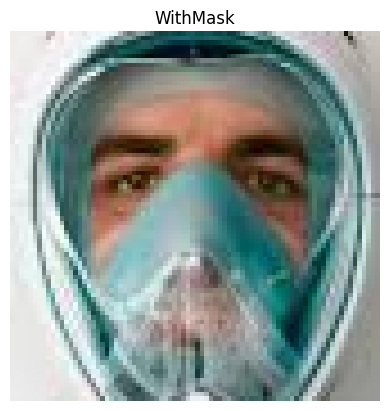

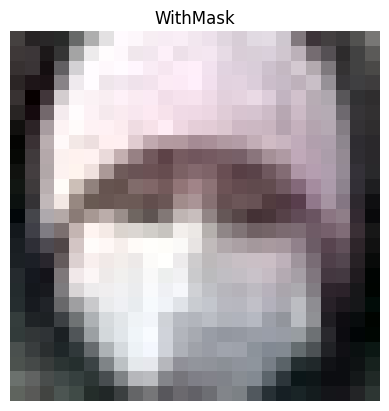

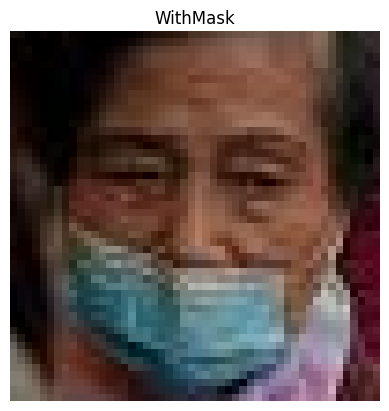

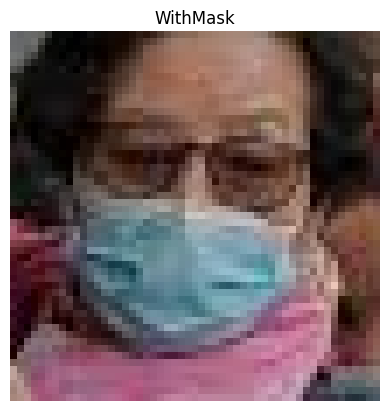

In [ ]:
for i in range(4):
    img, label = train_data[i]
    plt.imshow(img)
    plt.title(train_data.classes[label])
    plt.axis("off")
    plt.show()

#Analysis


A highly pixelated masked face (low resolution)




**Variation in mask types**: Includes respirators, surgical masks, and combinations with eyeglasses.



**Different image qualities**: One image is pixelated, which is useful for testing robustness under poor resolution.

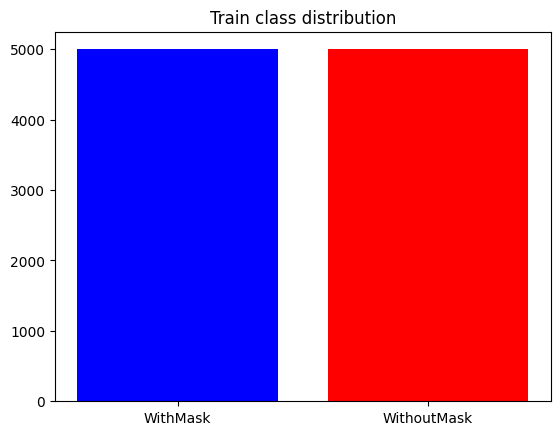

In [ ]:
class_counts = Counter(train_data.targets)
classes = train_data.classes

colors = ["blue", "red"]

plt.bar(classes, [class_counts[i] for i in range(len(classes))], color=colors)
plt.title("Train class distribution")
plt.show()

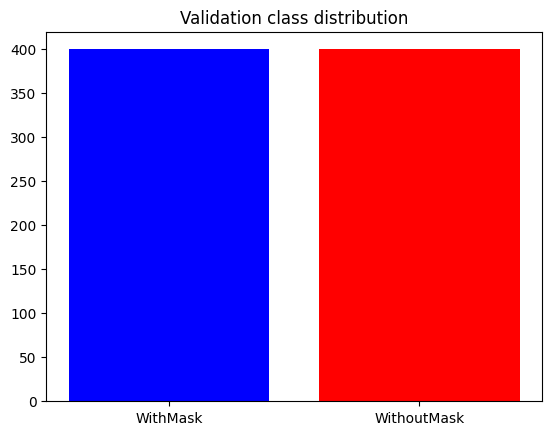

In [ ]:
class_counts = Counter(val_data.targets)
classes = val_data.classes

colors = ["blue", "red"]

plt.bar(classes, [class_counts[i] for i in range(len(classes))], color=colors)
plt.title("Validation class distribution")
plt.show()

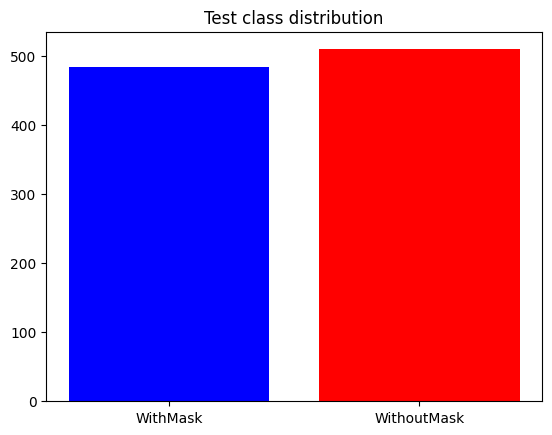

In [ ]:
class_counts = Counter(test_data.targets)
classes = test_data.classes

colors = ["blue", "red"]

plt.bar(classes, [class_counts[i] for i in range(len(classes))], color=colors)
plt.title("Test class distribution")
plt.show()

Image Size Distribution

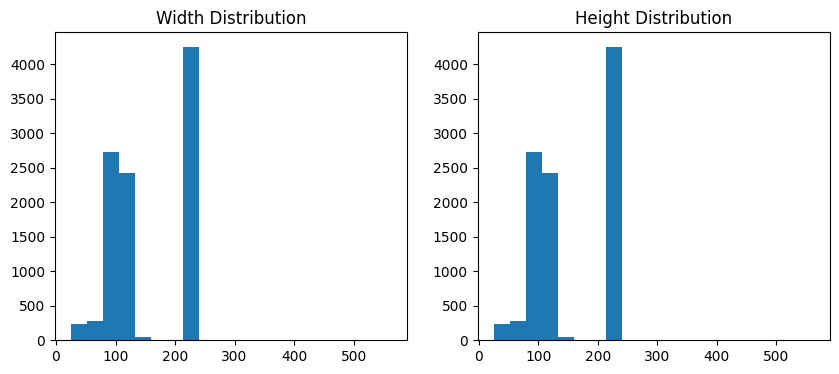

In [ ]:
sizes = [Image.open(img_path).size for img_path, _ in train_data.samples]
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(widths, bins=20)
plt.title("Width Distribution")

plt.subplot(1,2,2)
plt.hist(heights, bins=20)
plt.title("Height Distribution")

plt.show()

Brightness Distribution

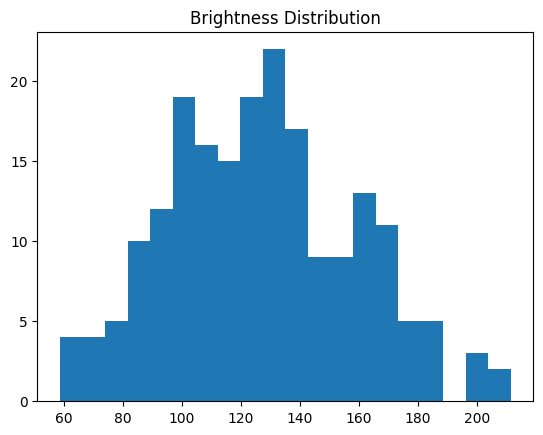

In [ ]:
import numpy as np

def get_brightness(img_path):
    img = Image.open(img_path).convert("L")
    return np.array(img).mean()

brightness = [get_brightness(img_path) for img_path, _ in random.sample(train_data.samples, 200)]

plt.hist(brightness, bins=20)
plt.title("Brightness Distribution")
plt.show()

RGB Channel Analysis

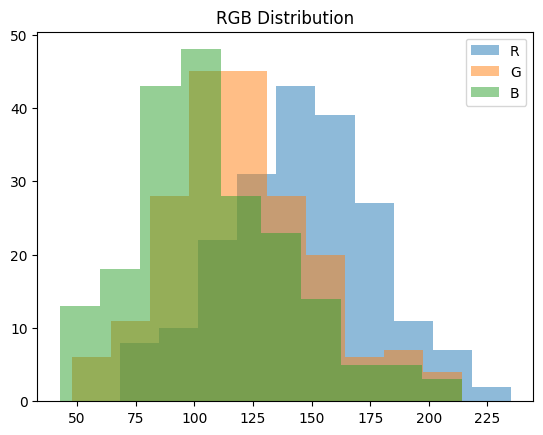

In [ ]:
r, g, b = [], [], []

for img_path, _ in random.sample(train_data.samples, 200):
    img = np.array(Image.open(img_path))
    r.append(img[:,:,0].mean())
    g.append(img[:,:,1].mean())
    b.append(img[:,:,2].mean())

plt.hist(r, alpha=0.5, label="R")
plt.hist(g, alpha=0.5, label="G")
plt.hist(b, alpha=0.5, label="B")
plt.legend()
plt.title("RGB Distribution")
plt.show()

Sample Grid

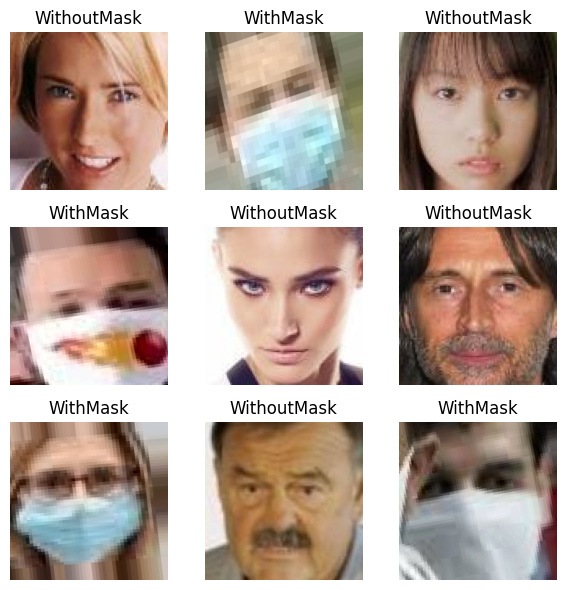

In [ ]:
fig, axes = plt.subplots(3,3, figsize=(6,6))

for ax in axes.flatten():
    img, label = train_data[random.randint(0, len(train_data)-1)]
    ax.imshow(img)
    ax.set_title(train_data.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

Augmentation (Flip, brightness (indoor/outdoor), rotation, noise)

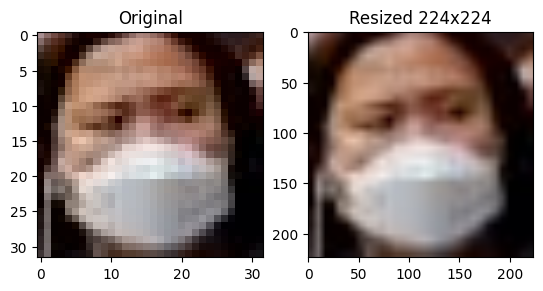

In [ ]:
img_path, label = train_data.samples[7]
img = Image.open(img_path)

resize_transform = transforms.Resize((224, 224))

resized_img = resize_transform(img)


plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(resized_img)
plt.title("Resized 224x224")

plt.show()


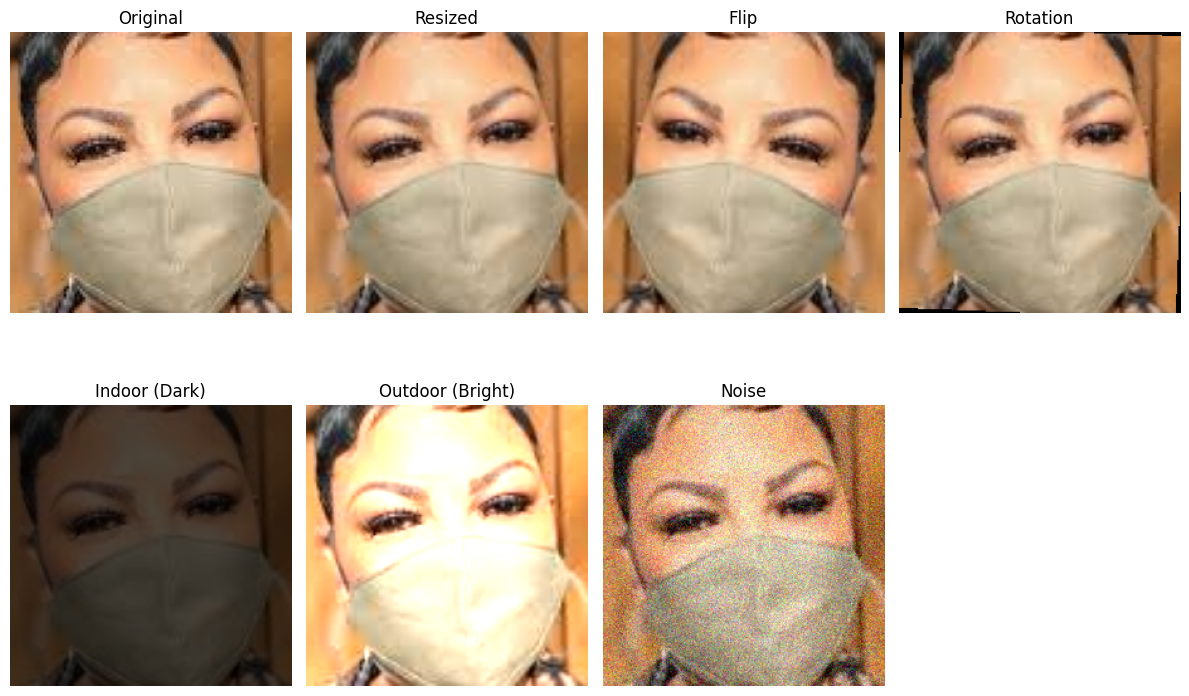

In [ ]:
from torchvision import transforms
from PIL import Image
import torch
import matplotlib.pyplot as plt

img_path, label = train_data.samples[10]
img = Image.open(img_path)

resize_transform = transforms.Resize((224, 224))
resized_img = resize_transform(img)

flip = transforms.RandomHorizontalFlip(p=1)
rotate = transforms.RandomRotation(20)

indoor_transform = transforms.ColorJitter(brightness=(0.3, 0.6))
outdoor_transform = transforms.ColorJitter(brightness=(1.2, 1.8))

def add_noise(img):
    img_tensor = transforms.ToTensor()(img)
    noise = torch.randn_like(img_tensor) * 0.1
    noisy_img = img_tensor + noise
    noisy_img = torch.clamp(noisy_img, 0, 1)
    return transforms.ToPILImage()(noisy_img)

flip_img = flip(resized_img)
rotate_img = rotate(resized_img)
noise_img = add_noise(resized_img)
indoor_img = indoor_transform(resized_img)
outdoor_img = outdoor_transform(resized_img)

plt.figure(figsize=(12,8))

plt.subplot(2,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(2,4,2)
plt.imshow(resized_img)
plt.title("Resized")
plt.axis("off")

plt.subplot(2,4,3)
plt.imshow(flip_img)
plt.title("Flip")
plt.axis("off")

plt.subplot(2,4,4)
plt.imshow(rotate_img)
plt.title("Rotation")
plt.axis("off")

plt.subplot(2,4,5)
plt.imshow(indoor_img)
plt.title("Indoor (Dark)")
plt.axis("off")

plt.subplot(2,4,6)
plt.imshow(outdoor_img)
plt.title("Outdoor (Bright)")
plt.axis("off")

plt.subplot(2,4,7)
plt.imshow(noise_img)
plt.title("Noise")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.5
    ),

    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
train_data = datasets.ImageFolder(
    root=os.path.join(path, "Face Mask Dataset/Train"),
    transform=train_transform
)

val_data = datasets.ImageFolder(
    root=os.path.join(path, "Face Mask Dataset/Validation"),
    transform=test_transform
)

test_data = datasets.ImageFolder(
    root=os.path.join(path, "Face Mask Dataset/Test"),
    transform=test_transform
)

In [ ]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

Member_4

In [ ]:
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_data_basic = datasets.ImageFolder(
    root=os.path.join(path, "Face Mask Dataset/Train"),
    transform=basic_transform
)

val_data_basic = datasets.ImageFolder(
    root=os.path.join(path, "Face Mask Dataset/Validation"),
    transform=basic_transform
)

test_data_basic = datasets.ImageFolder(
    root=os.path.join(path, "Face Mask Dataset/Test"),
    transform=basic_transform
)

train_loader_basic = DataLoader(train_data_basic, batch_size=32, shuffle=True)
val_loader_basic = DataLoader(val_data_basic, batch_size=32)
test_loader_basic = DataLoader(test_data_basic, batch_size=32)

Model with augmentation

In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_aug = models.mobilenet_v2(pretrained=True)

for param in model_aug.features.parameters():
    param.requires_grad = False

model_aug.classifier[1] = nn.Linear(model_aug.last_channel, 2)
model_aug = model_aug.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 191MB/s]


Model without augmentation

In [ ]:
model_basic = models.mobilenet_v2(pretrained=True)

for param in model_basic.features.parameters():
    param.requires_grad = False

model_basic.classifier[1] = nn.Linear(model_basic.last_channel, 2)
model_basic = model_basic.to(device)

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)
optimizer_basic = optim.Adam(model_basic.parameters(), lr=0.001)

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, epochs=10, patience=3, tag=""):
    train_accs, val_accs = [], []
    train_losses, val_losses = [], []

    best_val_acc = 0
    best_epoch = 0
    counter = 0  # for early stopping

    for epoch in range(epochs):

        # Train
        model.train()
        correct, total = 0, 0
        running_loss = 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        train_accs.append(train_acc)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        correct, total = 0, 0
        running_loss = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)

                outputs = model(imgs)
                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total
        val_loss = running_loss / len(val_loader)

        val_accs.append(val_acc)
        val_losses.append(val_loss)

        print(f"[{tag}] Epoch {epoch+1}: "
              f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, "
              f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

        # Best model and early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            counter = 0

            # save best model
            torch.save(model.state_dict(), f"best_model_{tag}.pth")

        else:
            counter += 1

        if counter >= patience:
            print(f"\n Early stopping at epoch {epoch+1}")
            break

    print(f"\n[{tag}] Best Epoch: {best_epoch} | Best Val Acc: {best_val_acc:.4f}")

    # Load best model
    model.load_state_dict(torch.load(f"best_model_{tag}.pth"))

    return model, train_accs, val_accs, train_losses, val_losses

In [ ]:
print("Training WITH augmentation")
model_aug, train_acc_aug, val_acc_aug, train_loss_aug, val_loss_aug = train_model(
    model_aug, train_loader, val_loader, optimizer_aug, tag="AUG"
)

print("\nTraining WITHOUT augmentation")
model_basic, train_acc_basic, val_acc_basic, train_loss_basic, val_loss_basic = train_model(
    model_basic, train_loader_basic, val_loader_basic, optimizer_basic, tag="NO_AUG"
)

Training WITH augmentation
[AUG] Epoch 1: Train Acc=0.9541, Val Acc=0.9850, Train Loss=0.1240, Val Loss=0.0710
[AUG] Epoch 2: Train Acc=0.9749, Val Acc=0.9900, Train Loss=0.0703, Val Loss=0.0328
[AUG] Epoch 3: Train Acc=0.9802, Val Acc=0.9900, Train Loss=0.0567, Val Loss=0.0224
[AUG] Epoch 4: Train Acc=0.9781, Val Acc=0.9962, Train Loss=0.0590, Val Loss=0.0129
[AUG] Epoch 5: Train Acc=0.9825, Val Acc=0.9938, Train Loss=0.0501, Val Loss=0.0150
[AUG] Epoch 6: Train Acc=0.9794, Val Acc=0.9962, Train Loss=0.0543, Val Loss=0.0124
[AUG] Epoch 7: Train Acc=0.9747, Val Acc=0.9938, Train Loss=0.0706, Val Loss=0.0155

 Early stopping at epoch 7

[AUG] Best Epoch: 4 | Best Val Acc: 0.9962

Training WITHOUT augmentation
[NO_AUG] Epoch 1: Train Acc=0.9662, Val Acc=0.9975, Train Loss=0.0985, Val Loss=0.0207
[NO_AUG] Epoch 2: Train Acc=0.9857, Val Acc=0.9975, Train Loss=0.0407, Val Loss=0.0113
[NO_AUG] Epoch 3: Train Acc=0.9863, Val Acc=0.9988, Train Loss=0.0391, Val Loss=0.0100
[NO_AUG] Epoch 4: Tra

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

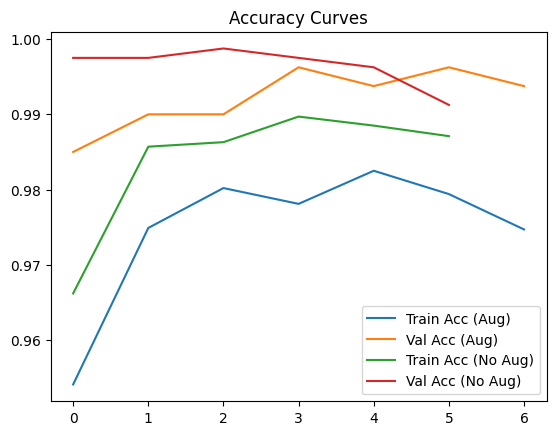

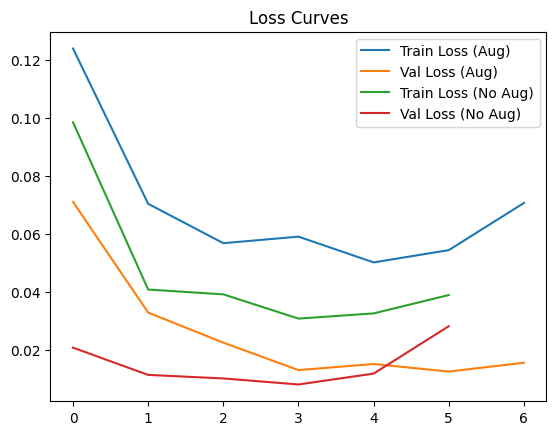

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(train_acc_aug, label="Train Acc (Aug)")
plt.plot(val_acc_aug, label="Val Acc (Aug)")
plt.plot(train_acc_basic, label="Train Acc (No Aug)")
plt.plot(val_acc_basic, label="Val Acc (No Aug)")

plt.legend()
plt.title("Accuracy Curves")
plt.show()

# Loss
plt.plot(train_loss_aug, label="Train Loss (Aug)")
plt.plot(val_loss_aug, label="Val Loss (Aug)")
plt.plot(train_loss_basic, label="Train Loss (No Aug)")
plt.plot(val_loss_basic, label="Val Loss (No Aug)")

plt.legend()
plt.title("Loss Curves")
plt.show()

Member_5

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

def evaluate(model, test_loader, name=""):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(f"\n{name} Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=train_data.classes))

    acc = accuracy_score(y_true, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    # Per-class accuracy
    print("\nPer-class accuracy:")
    per_class = cm.diagonal() / cm.sum(axis=1)
    for i, a in enumerate(per_class):
        print(f"{train_data.classes[i]}: {a:.4f}")

    return y_true, y_pred, cm

In [ ]:
y_true_aug, y_pred_aug, cm_aug = evaluate(model_aug, test_loader, "WITH AUG")

y_true_basic, y_pred_basic, cm_basic = evaluate(model_basic, test_loader_basic, "WITHOUT AUG")


WITH AUG Classification Report:

              precision    recall  f1-score   support

    WithMask       0.99      1.00      0.99       483
 WithoutMask       1.00      0.99      1.00       509

    accuracy                           0.99       992
   macro avg       0.99      1.00      0.99       992
weighted avg       0.99      0.99      0.99       992

WITH AUG Accuracy: 0.9950

Per-class accuracy:
WithMask: 0.9979
WithoutMask: 0.9921

WITHOUT AUG Classification Report:

              precision    recall  f1-score   support

    WithMask       1.00      1.00      1.00       483
 WithoutMask       1.00      1.00      1.00       509

    accuracy                           1.00       992
   macro avg       1.00      1.00      1.00       992
weighted avg       1.00      1.00      1.00       992

WITHOUT AUG Accuracy: 0.9970

Per-class accuracy:
WithMask: 0.9979
WithoutMask: 0.9961


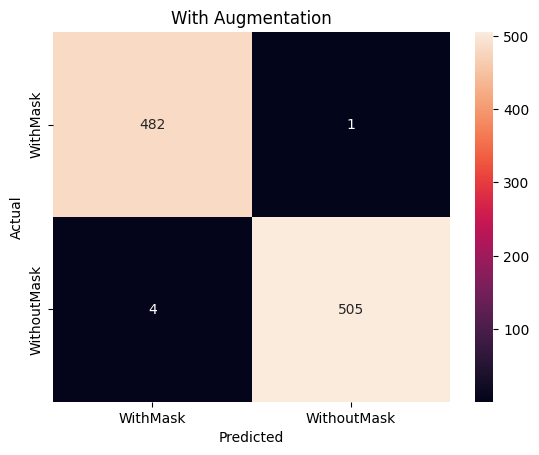

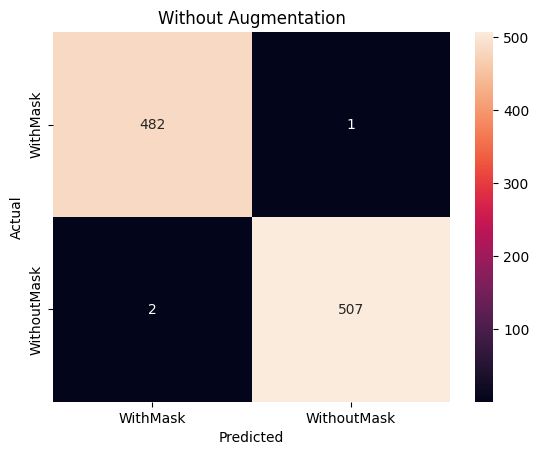

In [ ]:
import seaborn as sns

def plot_cm(cm, title):
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=train_data.classes,
                yticklabels=train_data.classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(cm_aug, "With Augmentation")
plot_cm(cm_basic, "Without Augmentation")